In [4]:
import random

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix
import numpy as np

max_val = 1
max_val += 1
y_true = np.random.randint(0, max_val, 100)
y_pred = np.random.randint(0, max_val, 100)

y_pred, y_true

(array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
        1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
        0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]),
 array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
        0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]))

In [5]:
accuracy_my = sum(y_pred == y_true) / len(y_pred)
accuracy_test = accuracy_score(y_true, y_pred)
accuracy_my, accuracy_test

(0.55, 0.55)

In [6]:
bac_my = 0
for i in range(max_val):
    tp = 0
    fp = 0
    for j in range(len(y_pred)):
        tp += y_pred[j] == y_true[j] and y_pred[j] == i
        fp += y_pred[j] == i and i != y_true[j]
    bac_my += tp / (tp + fp)

bac_my / max_val, balanced_accuracy_score(y_true, y_pred)

(0.5525893215576074, 0.5527375201288245)

In [7]:
pr = 0
tp = 0
fn = 0
fp = 0
for j in range(len(y_pred)):
    tp += y_pred[j] == y_true[j] and y_pred[j] == i 
    fp += y_pred[j] == i and i != y_true[j]
    fn += y_pred[j] != i and i == y_true[j]
pr = tp / (fp + tp)

pr, precision_score(y_true, y_pred)

(0.5094339622641509, 0.5094339622641509)

In [8]:
rc = tp / (fn + tp)

rc, recall_score(y_true, y_pred)

(0.5869565217391305, 0.5869565217391305)

In [9]:
f1 = 2 * (pr * rc) / (pr + rc)

f1, f1_score(y_true, y_pred)

(0.5454545454545454, 0.5454545454545454)

In [10]:
import matplotlib.pyplot as plt

[1.         0.95652174 0.84782609 0.7173913  0.58695652 0.47826087
 0.39130435 0.32608696 0.23913043 0.10869565 0.        ] [1.         0.96296296 0.90740741 0.75925926 0.64814815 0.55555556
 0.40740741 0.31481481 0.2037037  0.09259259 0.        ]


C:\Users\vav11\AppData\Local\Temp\ipykernel_2800\2896165367.py:23: RuntimeWarning: invalid value encountered in scalar divide
  pr[i] = tp / (tp + fp)


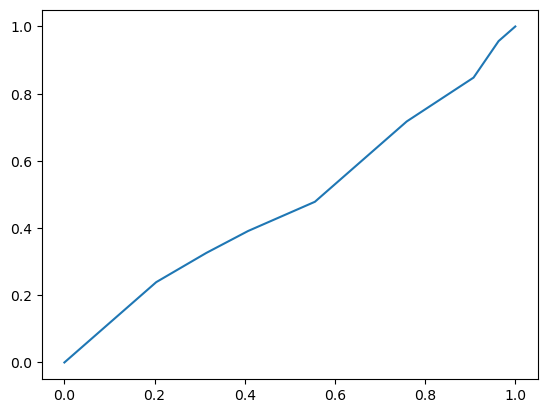

In [28]:
n = 11
tpr = np.zeros(n)
pr = np.zeros(n)
fpr = np.zeros(n)
rc = np.zeros(n)
P = np.random.rand(100)
for i in range(0, n):
    u = i / (n - 1)
    tp = 0.000
    tn = 0.000
    fp = 0.000
    fn = 0.000
    for j in range(len(y_true)):
        p = P[j]
        p = p >= u
        a = y_true[j]
        tp += a == p and a == 1
        fp += a != p and a == 0
        tn += a == p and a == 0
        fn += a != p and a == 1
    tpr[i] = tp / (tp + fn)
    fpr[i] = fp / (fp + tn)
    pr[i] = tp / (tp + fp)
    rc[i] = tp / (tp + fn)


print(tpr, fpr)
plt.plot(fpr, tpr)
plt.show()

[0.46       0.45833333 0.44318182 0.44594595 0.43548387 0.42307692
 0.45       0.46875    0.5        0.5               nan] [1.         0.95652174 0.84782609 0.7173913  0.58695652 0.47826087
 0.39130435 0.32608696 0.23913043 0.10869565 0.        ]


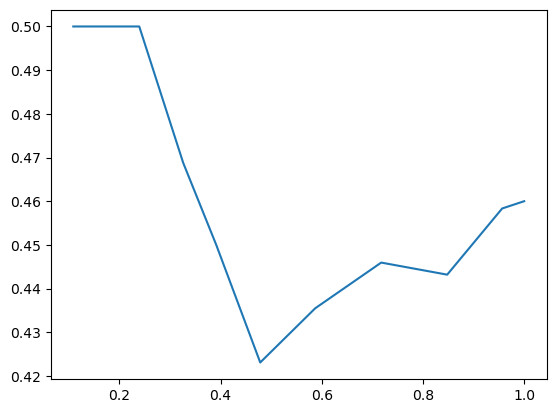

In [29]:
print(pr, rc)
plt.plot(rc, pr)
plt.show()